# 04 Final Analysis - Final Version with Equations and Clean Charts

This notebook is safe to run after the model notebook. It will:

1. Find and combine available prediction files.
2. Create `all_predictions.csv` if needed.
3. Create forecast error summaries.
4. Create RankIC summaries.
5. Create a simple long-short portfolio summary.
6. Create one final merged comparison table.
7. Save clean, presentation-ready plots for the paper/report.
8. Document the main equations used in the experiment.


## Equations used in this project

The target variable is the future return over horizon $h$:

$$
y_{t,h} = \frac{P_{t+h}}{P_t} - 1
$$

where $P_t$ is the close price at the cutoff date and $P_{t+h}$ is the future close price.

For models that forecast a future close price $\hat{P}_{t+h}$, the predicted return is:

$$
\hat{y}_{t,h} = \frac{\hat{P}_{t+h}}{P_t} - 1
$$

For the Naive / Random Walk baseline, the model assumes no price change:

$$
\hat{P}_{t+h} = P_t \quad \Rightarrow \quad \hat{y}_{t,h}=0
$$

Forecast error is:

$$
e_i = y_i - \hat{y}_i
$$

Mean Absolute Error (MAE):

$$
MAE = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

Root Mean Squared Error (RMSE):

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$

Directional Accuracy:

$$
DA = \frac{1}{n}\sum_{i=1}^{n} \mathbf{1}\left[\operatorname{sign}(y_i)=\operatorname{sign}(\hat{y}_i)\right]
$$

Cross-sectional RankIC is the Spearman rank correlation between predicted and realized returns across assets on the same date:

$$
RankIC_t = \rho_S\left(\operatorname{rank}(\hat{y}_{i,t}),\operatorname{rank}(y_{i,t})\right)
$$

Simple long-short portfolio return:

$$
R^{LS}_t = \frac{1}{K}\sum_{i \in TopK_t} y_{i,t} - \frac{1}{K}\sum_{j \in BottomK_t} y_{j,t}
$$

Approximate Sharpe ratio used for the diagnostic portfolio:

$$
Sharpe \approx \frac{\mathbb{E}[R^{LS}_t]}{\sigma(R^{LS}_t)}
$$

Important note: the Naive baseline is useful for MAE/RMSE, but it is not meaningful for RankIC or long-short portfolio ranking because it predicts the same return for every asset.


In [1]:
# Setup project root and imports
import os
import sys
from pathlib import Path

# Works when the notebook is run from either the project root or the notebooks folder.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Current working directory:", Path.cwd())
print("src exists:", (PROJECT_ROOT / "src").exists())


Project root: c:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project
Current working directory: c:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project
src exists: True


In [2]:
# Imports and paths
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from src.config import RESULTS_DIR, PLOTS_DIR, MIN_ASSETS_FOR_RANKIC
except Exception as e:
    print("Could not import src.config. Using fallback paths.")
    print("Reason:", repr(e))
    RESULTS_DIR = PROJECT_ROOT / "results" / "new_models"
    PLOTS_DIR = RESULTS_DIR / "plots"
    MIN_ASSETS_FOR_RANKIC = 100

RESULTS_DIR = Path(RESULTS_DIR)
PLOTS_DIR = Path(PLOTS_DIR)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("RESULTS_DIR:", RESULTS_DIR)
print("PLOTS_DIR:", PLOTS_DIR)
print("MIN_ASSETS_FOR_RANKIC:", MIN_ASSETS_FOR_RANKIC)

RESULTS_DIR: C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models
PLOTS_DIR: C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\plots
MIN_ASSETS_FOR_RANKIC: 100


In [3]:
# Helper functions

_CONSTANT_PRED_MODELS = {"Naive-RandomWalk"}
_SHARPE_ANNUAL_FACTOR = 12   # ~monthly cutoffs → 12 obs/year → annualise by √12
_LS_TOP_N    = 32            # 20% of 160-asset universe
_LS_BOTTOM_N = 32


def _parse_date_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in ["Date", "cutoff_date"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df


def _normalize_cutoff(predictions: pd.DataFrame) -> pd.DataFrame:
    """Normalize cutoff_date to YYYY-MM-DD string to fix mixed-format duplicates."""
    predictions = predictions.copy()
    if "cutoff_date" in predictions.columns:
        predictions["cutoff_date"] = (
            pd.to_datetime(predictions["cutoff_date"], format="mixed")
            .dt.strftime("%Y-%m-%d")
        )
    return predictions


def load_prediction_file(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = _parse_date_columns(df)

    rename_map = {}
    if "ds" in df.columns and "Date" not in df.columns:
        rename_map["ds"] = "Date"
    if "unique_id" in df.columns and "Ticker" not in df.columns:
        rename_map["unique_id"] = "Ticker"
    if "actual" in df.columns and "y_true" not in df.columns:
        rename_map["actual"] = "y_true"
    if "prediction" in df.columns and "y_pred" not in df.columns:
        rename_map["prediction"] = "y_pred"
    df = df.rename(columns=rename_map)

    required = ["Date", "Ticker", "Model", "Horizon", "y_true", "y_pred"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{path.name} is missing required columns: {missing}. Columns found: {list(df.columns)}")

    df["Horizon"] = pd.to_numeric(df["Horizon"], errors="coerce")
    df["y_true"]  = pd.to_numeric(df["y_true"],  errors="coerce")
    df["y_pred"]  = pd.to_numeric(df["y_pred"],  errors="coerce")

    if "cutoff_date" not in df.columns:
        df["cutoff_date"] = pd.NaT

    return df


def combine_prediction_files(results_dir: Path) -> pd.DataFrame:
    preferred_files = [
        "naive_predictions.csv",
        "classical_predictions.csv",
        "neural_predictions.csv",
        "chronos_predictions.csv",
        "kronos_predictions.csv",
        "foundation_predictions.csv",
        "embedding_predictions.csv",
        "barrier_predictions.csv",
    ]

    files = []
    for name in preferred_files:
        p = results_dir / name
        if p.exists():
            files.append(p)

    for p in sorted(results_dir.glob("*_predictions.csv")):
        if p.name in preferred_files:
            continue
        if p.name in ["all_predictions.csv"]:
            continue
        files.append(p)

    if not files:
        raise FileNotFoundError(f"No prediction files found in {results_dir}.")

    dfs = []
    print("Prediction files found:")
    for p in files:
        try:
            df = load_prediction_file(p)
            dfs.append(df)
            print(f"  loaded {p.name}: {df.shape}")
        except Exception as e:
            print(f"  skipped {p.name}: {e}")

    if not dfs:
        raise ValueError("Prediction files were found, but none could be loaded correctly.")

    all_df = pd.concat(dfs, ignore_index=True)
    all_df = _parse_date_columns(all_df)
    all_df = all_df.dropna(subset=["Date", "Ticker", "Model", "Horizon", "y_true", "y_pred"])

    dedup_cols = ["Date", "Ticker", "Model", "Horizon"]
    all_df = all_df.drop_duplicates(subset=dedup_cols, keep="last")
    all_df = all_df.sort_values(["Model", "Horizon", "Ticker", "Date"]).reset_index(drop=True)
    return all_df


def directional_accuracy(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.sign(y_true[mask]) == np.sign(y_pred[mask])))


def summarize_predictions(predictions: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (model, horizon), g in predictions.groupby(["Model", "Horizon"], dropna=False):
        g = g.dropna(subset=["y_true", "y_pred"])
        if g.empty:
            continue
        err  = g["y_true"].astype(float) - g["y_pred"].astype(float)
        mae  = float(np.mean(np.abs(err)))
        rmse = float(np.sqrt(np.mean(err ** 2)))
        rows.append({
            "Model":   model,
            "Horizon": int(horizon) if pd.notna(horizon) else horizon,
            "N":       int(len(g)),
            "MAE":     mae,
            "RMSE":    rmse,
            "DirectionalAccuracy": directional_accuracy(g["y_true"], g["y_pred"]),
            "MeanActualReturn":    float(g["y_true"].mean()),
            "MeanPredReturn":      float(g["y_pred"].mean()),
        })
    if not rows:
        return pd.DataFrame(columns=["Model", "Horizon", "N", "MAE", "RMSE",
                                      "DirectionalAccuracy", "MeanActualReturn", "MeanPredReturn"])
    return pd.DataFrame(rows).sort_values(["Horizon", "MAE", "Model"]).reset_index(drop=True)


def cross_sectional_rank_ic(predictions: pd.DataFrame, min_assets: int = 50) -> pd.DataFrame:
    from scipy.stats import spearmanr
    predictions = _normalize_cutoff(predictions)
    group_col = "cutoff_date" if "cutoff_date" in predictions.columns else "Date"

    rows = []
    if predictions.empty:
        return pd.DataFrame(columns=["Model", "Horizon", "Date", "RankIC", "N_Assets"])

    for (model, horizon), mg in predictions.groupby(["Model", "Horizon"]):
        if model in _CONSTANT_PRED_MODELS:
            continue
        for cutoff, g in mg.groupby(group_col):
            g = g.dropna(subset=["y_true", "y_pred"])
            g = g.drop_duplicates(subset=["Ticker"], keep="last")
            if len(g) < min_assets:
                continue
            if g["y_pred"].nunique() < 2:
                continue
            ic, _ = spearmanr(g["y_pred"].astype(float), g["y_true"].astype(float))
            if np.isfinite(ic):
                rows.append({
                    "Model":    model,
                    "Horizon":  int(horizon) if pd.notna(horizon) else horizon,
                    "Date":     cutoff,
                    "RankIC":   float(ic),
                    "N_Assets": int(len(g)),
                })

    return pd.DataFrame(rows)


def summarize_rank_ic(rank_ic: pd.DataFrame) -> pd.DataFrame:
    if rank_ic.empty:
        return pd.DataFrame(columns=["Model", "Horizon", "RankIC_Mean", "RankIC_Median", "RankIC_Std", "RankIC_N"])
    out = (
        rank_ic.groupby(["Model", "Horizon"])
        .agg(
            RankIC_Mean=("RankIC", "mean"),
            RankIC_Median=("RankIC", "median"),
            RankIC_Std=("RankIC", "std"),
            RankIC_N=("RankIC", "count"),
        )
        .reset_index()
    )
    return out


def long_short_portfolio_summary(
    predictions: pd.DataFrame,
    top_n: int = _LS_TOP_N,
    bottom_n: int = _LS_BOTTOM_N,
) -> pd.DataFrame:
    predictions = _normalize_cutoff(predictions)
    group_col = "cutoff_date" if "cutoff_date" in predictions.columns else "Date"

    required = ["Ticker", "Model", "Horizon", "y_true", "y_pred"]
    missing = [c for c in required if c not in predictions.columns]
    if missing:
        raise ValueError(f"Missing columns for portfolio summary: {missing}")

    rows = []
    for (model, horizon), mg in predictions.groupby(["Model", "Horizon"]):
        if model in _CONSTANT_PRED_MODELS:
            continue
        for cutoff, g in mg.groupby(group_col):
            g = g.dropna(subset=["y_true", "y_pred"]).copy()
            g = g.drop_duplicates(subset=["Ticker"], keep="last")
            if len(g) < top_n + bottom_n:
                continue
            if g["y_pred"].nunique() < 2:
                continue
            ranked      = g.sort_values("y_pred", ascending=False)
            long_return  = float(ranked.head(top_n)["y_true"].mean())
            short_return = float(ranked.tail(bottom_n)["y_true"].mean())
            rows.append({
                "Model":          model,
                "Horizon":        int(horizon) if pd.notna(horizon) else horizon,
                "Date":           cutoff,
                "LongReturn":     long_return,
                "ShortReturn":    short_return,
                "LongShortReturn": long_return - short_return,
                "N_Assets":       int(g["Ticker"].nunique()),
            })

    daily = pd.DataFrame(rows)
    if daily.empty:
        return pd.DataFrame(columns=[
            "Model", "Horizon", "MeanLongShortReturn",
            "VolLongShortReturn", "SharpeApprox", "N_Dates"
        ])

    summary_rows = []
    for (model, horizon), g in daily.groupby(["Model", "Horizon"]):
        mean_ret = float(g["LongShortReturn"].mean())
        vol_ret  = float(g["LongShortReturn"].std(ddof=1))
        sharpe   = (mean_ret / vol_ret * np.sqrt(_SHARPE_ANNUAL_FACTOR)
                    if vol_ret > 0 and np.isfinite(vol_ret) else np.nan)
        summary_rows.append({
            "Model":               model,
            "Horizon":             int(horizon) if pd.notna(horizon) else horizon,
            "MeanLongShortReturn": mean_ret,
            "VolLongShortReturn":  vol_ret,
            "SharpeApprox":        sharpe,
            "N_Dates":             int(len(g)),
        })

    return pd.DataFrame(summary_rows).sort_values(
        ["Horizon", "SharpeApprox"], ascending=[True, False]
    ).reset_index(drop=True)

## 1. Find existing prediction files

In [4]:
print("CSV files in results folder:")
for f in sorted(RESULTS_DIR.glob("*.csv")):
    print("-", f.name)


CSV files in results folder:
- all_predictions.csv
- chronos_predictions.csv
- chronos_summary.csv
- classical_predictions.csv
- classical_summary.csv
- embedding_predictions.csv
- final_comparison_all.csv
- final_model_comparison.csv
- kronos_predictions.csv
- kronos_summary.csv
- model_summary.csv
- naive_predictions.csv
- neural_predictions.csv
- neural_summary.csv
- portfolio_summary.csv
- rank_ic_by_date.csv
- rank_ic_summary.csv
- summary.csv


## 2. Combine predictions

This cell creates or overwrites `all_predictions.csv` from available model prediction files.


In [5]:
all_predictions = combine_prediction_files(RESULTS_DIR)

# Winsorize y_true at 1st/99th percentile per horizon to remove outlier distortion
for h, g in all_predictions.groupby('Horizon'):
    lo = g['y_true'].quantile(0.01)
    hi = g['y_true'].quantile(0.99)
    all_predictions.loc[g.index, 'y_true'] = g['y_true'].clip(lo, hi)
print('y_true winsorized at 1%/99% per horizon')
all_predictions_path = RESULTS_DIR / "all_predictions.csv"
all_predictions.to_csv(all_predictions_path, index=False)

print("Saved:", all_predictions_path)
print("Shape:", all_predictions.shape)
print("Models:")
print(all_predictions["Model"].value_counts())

display(all_predictions.head())


Prediction files found:
  loaded naive_predictions.csv: (5760, 10)
  loaded classical_predictions.csv: (17280, 10)
  loaded neural_predictions.csv: (11520, 10)
  loaded chronos_predictions.csv: (5760, 10)
  loaded kronos_predictions.csv: (5760, 10)
  loaded embedding_predictions.csv: (23040, 10)
y_true winsorized at 1%/99% per horizon
Saved: C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\all_predictions.csv
Shape: (63360, 10)
Models:
Model
AutoETS             5760
AutoTheta           5760
Chronos-ZeroShot    5760
Kronos-ZeroShot     5760
NBEATS              5760
NBEATS-Emb-16       5760
NBEATS-Emb-32       5760
NBEATS-Emb-8        5760
NBEATS-NoEmb        5760
Naive-RandomWalk    5760
PatchTST            5760
Name: count, dtype: int64


,Date,Ticker,Model,Horizon,y_true,y_pred,cutoff_date,last_close,pred_close,actual_close
0,2024-11-21,AAPL,AutoETS,1,-0.002096,-3.331613e-07,2024-11-20,229.000000,228.999924,228.520004
1,2024-12-20,AAPL,AutoETS,1,0.018816,-6.719512e-07,2024-12-19,249.789993,249.789825,254.490005
2,2025-01-20,AAPL,AutoETS,1,0.000000,-7.298316e-07,2025-01-17,229.979996,229.979828,229.979996
3,2025-02-18,AAPL,AutoETS,1,-0.000531,2.220446e-16,2025-02-17,244.600006,244.600006,244.470001
4,2025-03-19,AAPL,AutoETS,1,0.011989,6.456773e-07,2025-03-18,212.690002,212.690140,215.240005


## 3. Create summary tables

In [6]:
summary = summarize_predictions(all_predictions)
summary_path = RESULTS_DIR / "summary.csv"
summary.to_csv(summary_path, index=False)

print("Saved:", summary_path)
display(summary)


Saved: C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\summary.csv


,Model,Horizon,N,MAE,RMSE,DirectionalAccuracy,MeanActualReturn,MeanPredReturn
0,Naive-RandomWalk,1,2880,0.012714,0.018121,0.050000,0.001482,0.000000
1,AutoETS,1,2880,0.012720,0.018140,0.475694,0.001482,0.000151
2,AutoTheta,1,2880,0.012857,0.018153,0.506597,0.001482,0.000200
3,NBEATS,1,2880,0.013024,0.018487,0.480208,0.001482,0.000450
4,NBEATS-NoEmb,1,2880,0.013142,0.018312,0.530903,0.001482,0.002833
5,NBEATS-Emb-16,1,2880,0.013750,0.018677,0.501389,0.001482,0.001617
6,PatchTST,1,2880,0.013823,0.019476,0.459722,0.001482,0.000930
7,NBEATS-Emb-8,1,2880,0.013855,0.019044,0.480903,0.001482,0.000147
8,NBEATS-Emb-32,1,2880,0.013958,0.019179,0.460069,0.001482,0.000053
9,Chronos-ZeroShot,1,2880,0.014147,0.019981,0.482986,0.001482,0.002292


In [7]:
rank_ic = cross_sectional_rank_ic(all_predictions, min_assets=MIN_ASSETS_FOR_RANKIC)
rank_ic_path = RESULTS_DIR / "rank_ic_by_date.csv"
rank_ic.to_csv(rank_ic_path, index=False)

rank_summary = summarize_rank_ic(rank_ic)
rank_summary_path = RESULTS_DIR / "rank_ic_summary.csv"
rank_summary.to_csv(rank_summary_path, index=False)

print("Saved:", rank_ic_path)
print("Saved:", rank_summary_path)
print("RankIC rows:", len(rank_ic))
display(rank_summary)


Saved: C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\rank_ic_by_date.csv
Saved: C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\rank_ic_summary.csv
RankIC rows: 360


,Model,Horizon,RankIC_Mean,RankIC_Median,RankIC_Std,RankIC_N
0,AutoETS,1,0.018528,-0.000766,0.141270,18
1,AutoETS,5,0.048661,0.034562,0.119243,18
2,AutoTheta,1,0.056106,0.053114,0.192634,18
3,AutoTheta,5,0.076604,0.126059,0.194431,18
4,Chronos-ZeroShot,1,0.011638,0.041555,0.115480,18
5,Chronos-ZeroShot,5,0.005746,0.017423,0.168783,18
6,Kronos-ZeroShot,1,-0.012027,-0.032107,0.161204,18
7,Kronos-ZeroShot,5,0.016529,-0.010685,0.195650,18
8,NBEATS,1,0.027165,0.023734,0.105780,18
9,NBEATS,5,0.009539,-0.011497,0.164795,18


## 4. Portfolio-style long-short evaluation

This is a simple diagnostic that ranks assets by predicted return on each date.


In [8]:
portfolio_summary = long_short_portfolio_summary(
    all_predictions,
    top_n=_LS_TOP_N,
    bottom_n=_LS_BOTTOM_N,
)

portfolio_summary_path = RESULTS_DIR / "portfolio_summary.csv"
portfolio_summary.to_csv(portfolio_summary_path, index=False)

print("Saved:", portfolio_summary_path)
display(portfolio_summary)


Saved: C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\portfolio_summary.csv


,Model,Horizon,MeanLongShortReturn,VolLongShortReturn,SharpeApprox,N_Dates
0,NBEATS-NoEmb,1,0.002426,0.006169,1.362108,18
1,AutoTheta,1,0.002801,0.010564,0.918395,18
2,Chronos-ZeroShot,1,0.000780,0.005153,0.524083,18
3,AutoETS,1,0.000629,0.005828,0.373666,18
4,NBEATS,1,0.000458,0.005032,0.315017,18
5,NBEATS-Emb-32,1,-0.000138,0.005227,-0.091311,18
6,PatchTST,1,-0.000335,0.009797,-0.118475,18
7,NBEATS-Emb-16,1,-0.000751,0.006506,-0.399900,18
8,Kronos-ZeroShot,1,-0.001224,0.007692,-0.551138,18
9,NBEATS-Emb-8,1,-0.001169,0.005488,-0.737786,18


In [9]:
final_comparison = (
    summary.merge(rank_summary, on=["Model", "Horizon"], how="left")
    .merge(portfolio_summary, on=["Model", "Horizon"], how="left")
)

final_comparison = final_comparison.sort_values(
    ["Horizon", "MAE", "RMSE"]
).reset_index(drop=True)

final_path = RESULTS_DIR / "final_model_comparison.csv"
final_comparison.to_csv(final_path, index=False)

print("Saved:", final_path)
display(final_comparison)


Saved: C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\final_model_comparison.csv


,Model,Horizon,N,MAE,RMSE,DirectionalAccuracy,MeanActualReturn,MeanPredReturn,RankIC_Mean,RankIC_Median,RankIC_Std,RankIC_N,MeanLongShortReturn,VolLongShortReturn,SharpeApprox,N_Dates
0,Naive-RandomWalk,1,2880,0.012714,0.018121,0.050000,0.001482,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AutoETS,1,2880,0.012720,0.018140,0.475694,0.001482,0.000151,0.018528,-0.000766,0.141270,18.0,0.000629,0.005828,0.373666,18.0
2,AutoTheta,1,2880,0.012857,0.018153,0.506597,0.001482,0.000200,0.056106,0.053114,0.192634,18.0,0.002801,0.010564,0.918395,18.0
3,NBEATS,1,2880,0.013024,0.018487,0.480208,0.001482,0.000450,0.027165,0.023734,0.105780,18.0,0.000458,0.005032,0.315017,18.0
4,NBEATS-NoEmb,1,2880,0.013142,0.018312,0.530903,0.001482,0.002833,0.057573,0.040749,0.131286,18.0,0.002426,0.006169,1.362108,18.0
5,NBEATS-Emb-16,1,2880,0.013750,0.018677,0.501389,0.001482,0.001617,-0.020098,-0.027287,0.135023,18.0,-0.000751,0.006506,-0.399900,18.0
6,PatchTST,1,2880,0.013823,0.019476,0.459722,0.001482,0.000930,-0.050805,-0.047179,0.208755,18.0,-0.000335,0.009797,-0.118475,18.0
7,NBEATS-Emb-8,1,2880,0.013855,0.019044,0.480903,0.001482,0.000147,0.019067,0.012562,0.122627,18.0,-0.001169,0.005488,-0.737786,18.0
8,NBEATS-Emb-32,1,2880,0.013958,0.019179,0.460069,0.001482,0.000053,-0.013210,0.009367,0.123246,18.0,-0.000138,0.005227,-0.091311,18.0
9,Chronos-ZeroShot,1,2880,0.014147,0.019981,0.482986,0.001482,0.002292,0.011638,0.041555,0.115480,18.0,0.000780,0.005153,0.524083,18.0


## 5. Quick interpretation table

The next cell creates a small helper table showing the best model per horizon for the main metrics. Use it only as a guide. In the paper, explain that lower MAE/RMSE is better, while higher Directional Accuracy, RankIC, and Sharpe are better.


In [10]:
def best_by_metric(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    specs = [
        ("MAE", "min", "Lower is better"),
        ("RMSE", "min", "Lower is better"),
        ("DirectionalAccuracy", "max", "Higher is better"),
        ("RankIC_Mean", "max", "Higher is better"),
        ("SharpeApprox", "max", "Higher is better"),
    ]
    for horizon, hdf in df.groupby("Horizon"):
        for metric, direction, note in specs:
            if metric not in hdf.columns:
                continue
            sub = hdf.dropna(subset=[metric]).copy()
            # Naive RankIC/Sharpe are not meaningful because predictions are constant.
            if metric in ["RankIC_Mean", "SharpeApprox"]:
                sub = sub[sub["Model"] != "Naive-RandomWalk"]
            if sub.empty:
                continue
            idx = sub[metric].idxmin() if direction == "min" else sub[metric].idxmax()
            rows.append({
                "Horizon": horizon,
                "Metric": metric,
                "BestModel": sub.loc[idx, "Model"],
                "BestValue": sub.loc[idx, metric],
                "Interpretation": note,
            })
    return pd.DataFrame(rows)

best_models = best_by_metric(final_comparison)
display(best_models)


,Horizon,Metric,BestModel,BestValue,Interpretation
0,1,MAE,Naive-RandomWalk,0.012714,Lower is better
1,1,RMSE,Naive-RandomWalk,0.018121,Lower is better
2,1,DirectionalAccuracy,NBEATS-NoEmb,0.530903,Higher is better
3,1,RankIC_Mean,NBEATS-NoEmb,0.057573,Higher is better
4,1,SharpeApprox,NBEATS-NoEmb,1.362108,Higher is better
5,5,MAE,NBEATS,0.028225,Lower is better
6,5,RMSE,AutoTheta,0.038386,Lower is better
7,5,DirectionalAccuracy,AutoTheta,0.553125,Higher is better
8,5,RankIC_Mean,AutoTheta,0.076604,Higher is better
9,5,SharpeApprox,PatchTST,1.152739,Higher is better


## 6. Clean presentation-ready plots

These plots are designed to be easy to explain in the paper or final presentation:

- **MAE and RMSE:** lower is better.
- **Directional Accuracy:** higher is better. The dashed line marks 50%, which is random direction guessing.
- **RankIC:** values above 0 mean better ranking of assets by future return. Values close to 0 mean weak ranking signal.
- **Portfolio Sharpe:** values above 0 mean the long-short diagnostic portfolio had positive return per unit of risk.


In [11]:
# Update MODEL_ORDER and MODEL_LABELS to include embedding models


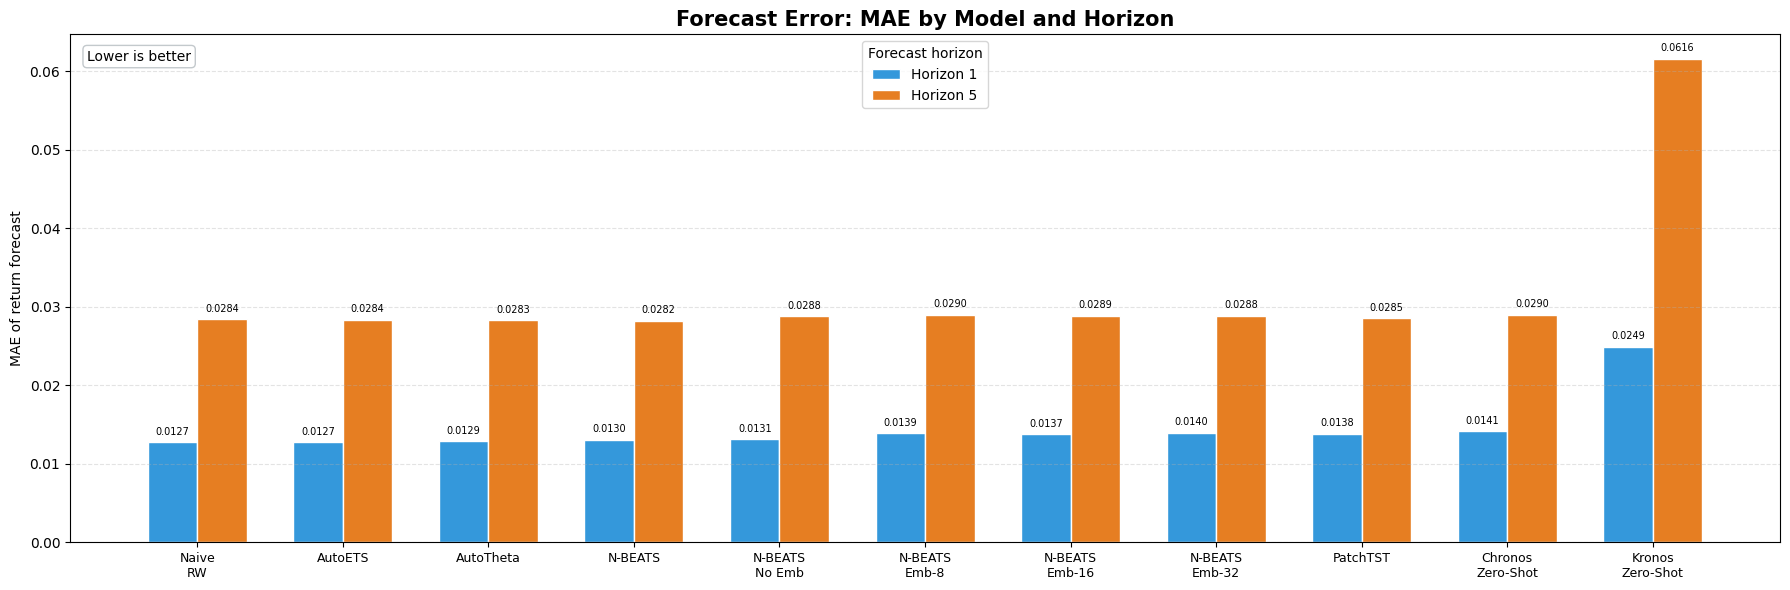

Saved: C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\plots\mae_clean.png


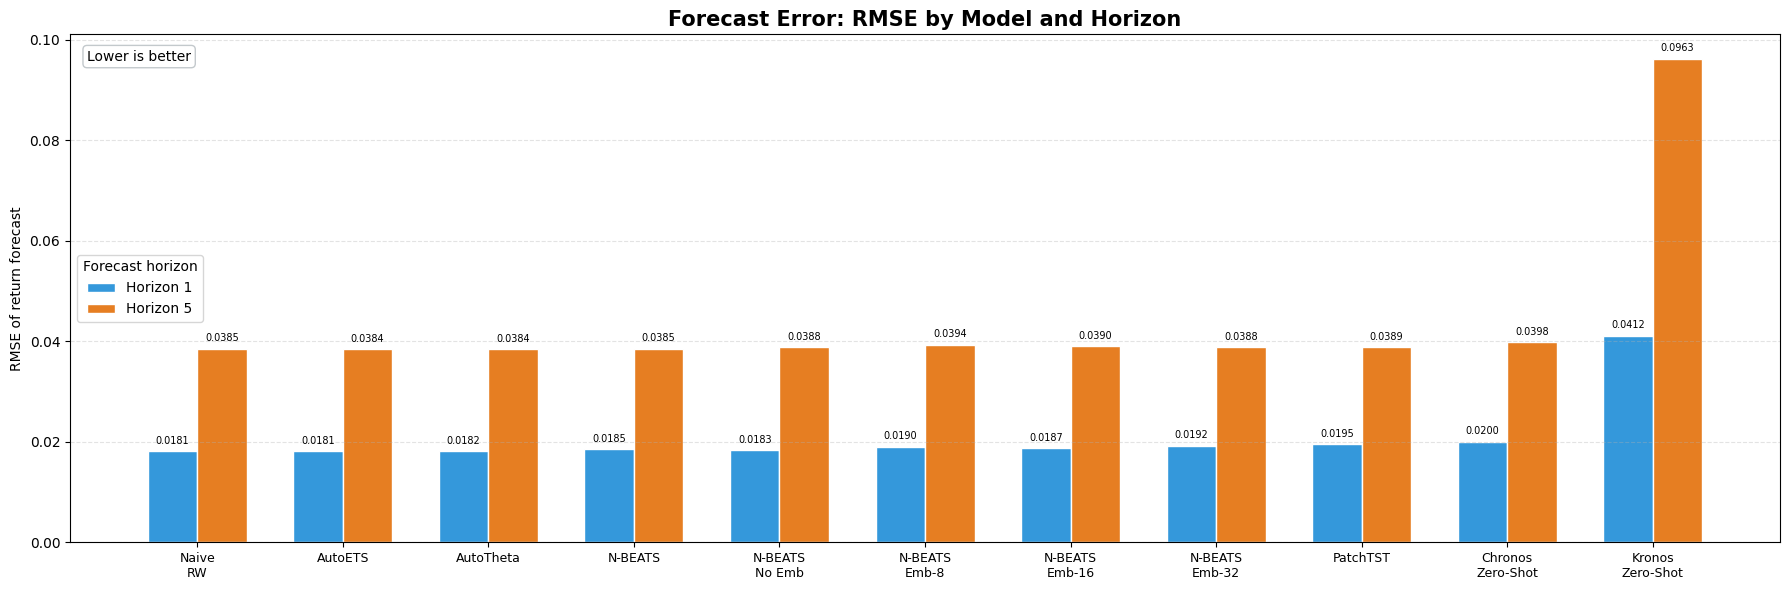

Saved: C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\plots\rmse_clean.png


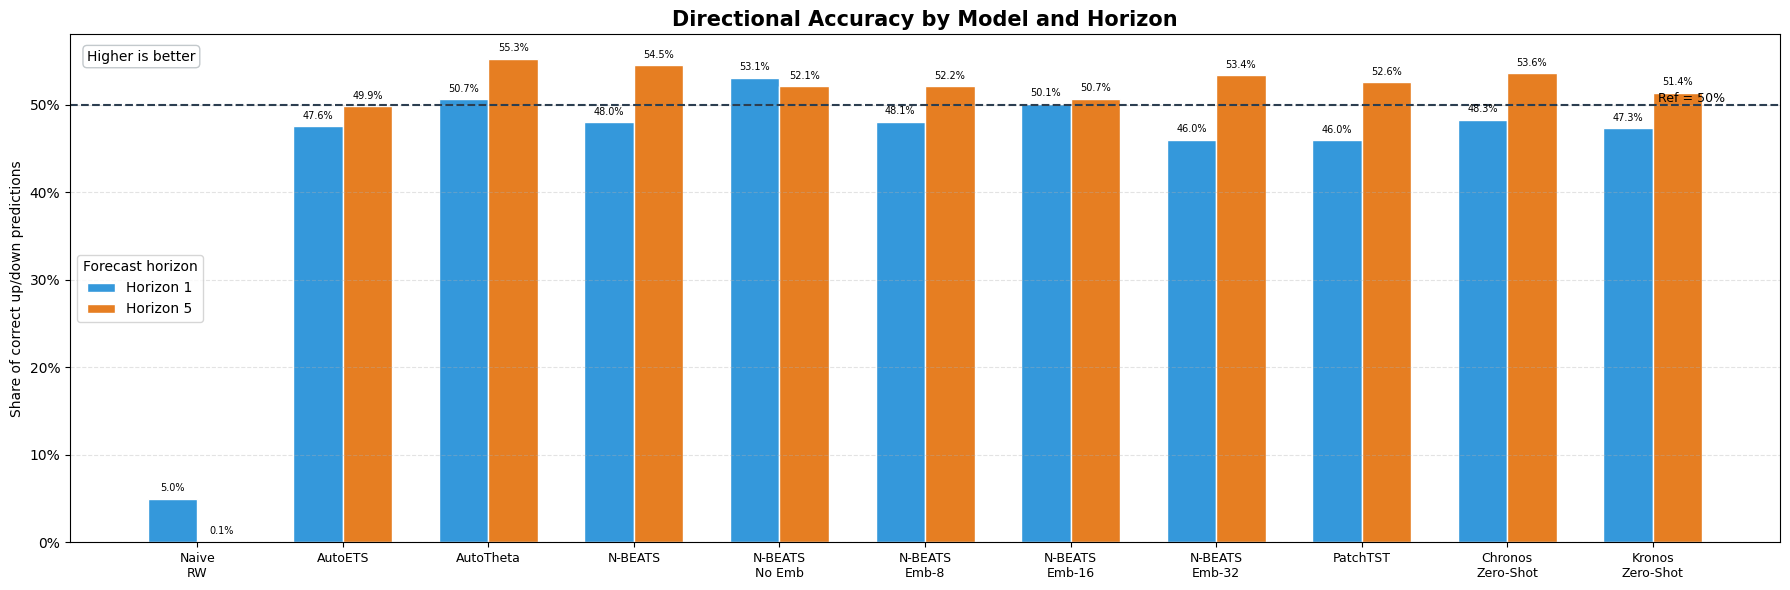

Saved: C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\plots\directional_accuracy_clean.png


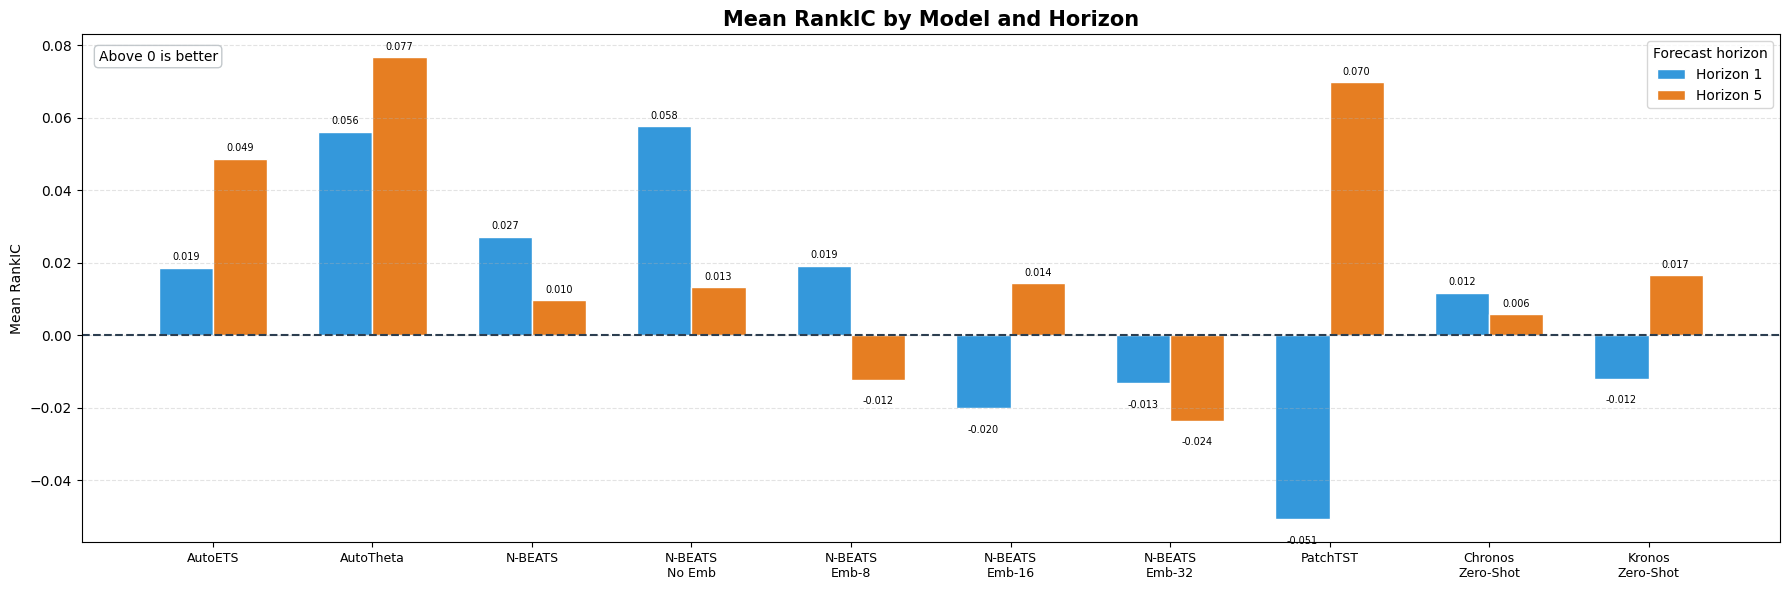

Saved: C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\plots\rankic_clean.png


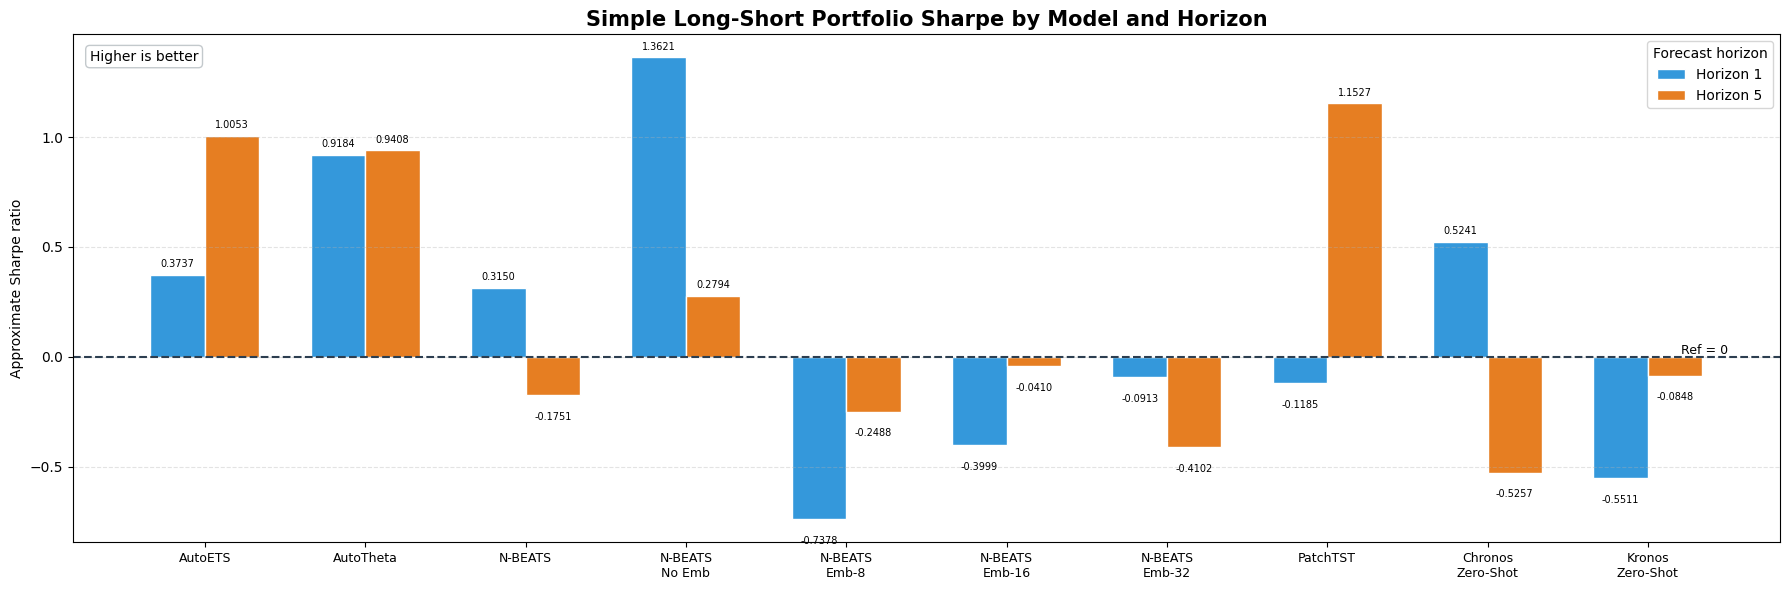

Saved: C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\plots\portfolio_sharpe_clean.png


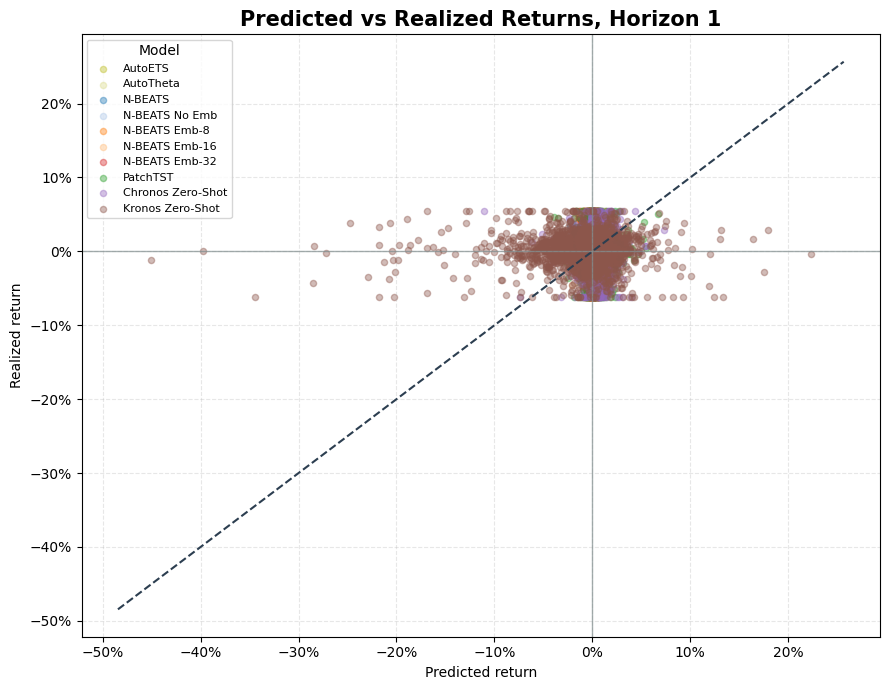

Saved: C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\plots\predicted_vs_actual_returns_h1.png


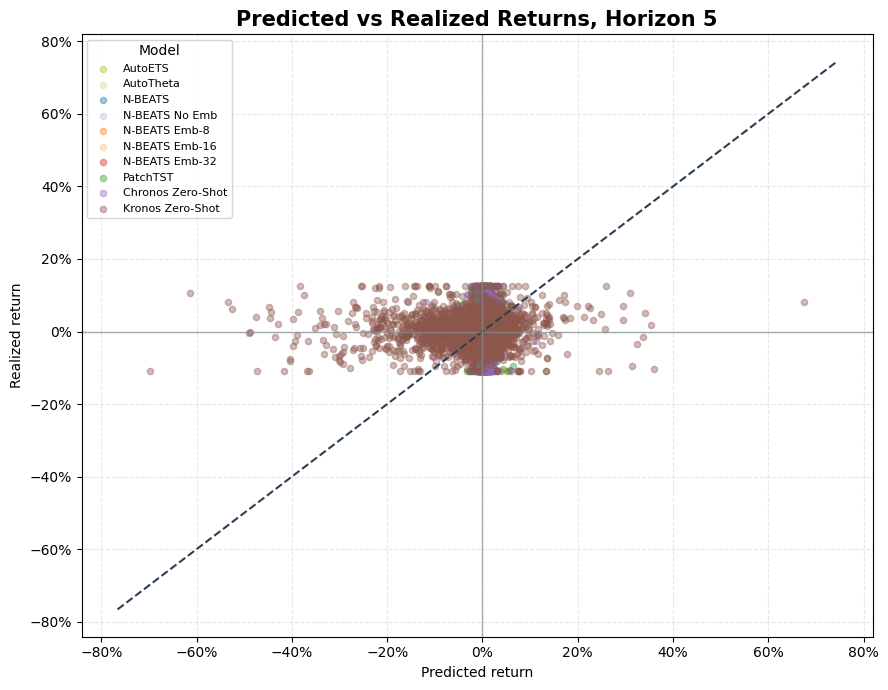

Saved: C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\plots\predicted_vs_actual_returns_h5.png


In [12]:
# Clean, easy-to-read plots with consistent colors
from matplotlib.ticker import PercentFormatter

MODEL_ORDER = [
    "Naive-RandomWalk",
    "AutoETS",
    "AutoTheta",
    "NBEATS",
    "NBEATS-NoEmb",
    "NBEATS-Emb-8",
    "NBEATS-Emb-16",
    "NBEATS-Emb-32",
    "PatchTST",
    "Chronos-ZeroShot",
    "Kronos-ZeroShot",
    "BarrierRF",
    "BarrierXGB",
]

MODEL_LABELS = {
    "Naive-RandomWalk": "Naive\nRW",
    "AutoETS":          "AutoETS",
    "AutoTheta":        "AutoTheta",
    "NBEATS":           "N-BEATS",
    "NBEATS-NoEmb":     "N-BEATS\nNo Emb",
    "NBEATS-Emb-8":     "N-BEATS\nEmb-8",
    "NBEATS-Emb-16":    "N-BEATS\nEmb-16",
    "NBEATS-Emb-32":    "N-BEATS\nEmb-32",
    "PatchTST":         "PatchTST",
    "Chronos-ZeroShot": "Chronos\nZero-Shot",
    "Kronos-ZeroShot":  "Kronos\nZero-Shot",
    "BarrierRF":        "Barrier\nRF",
    "BarrierXGB":       "Barrier\nXGB",
}

MODEL_COLORS = {
    "Naive-RandomWalk": "#7f8c8d",
    "AutoETS":          "#bcbd22",
    "AutoTheta":        "#dbdb8d",
    "NBEATS":           "#1f77b4",
    "NBEATS-NoEmb":     "#aec7e8",
    "NBEATS-Emb-8":     "#ff7f0e",
    "NBEATS-Emb-16":    "#ffbb78",
    "NBEATS-Emb-32":    "#d62728",
    "PatchTST":         "#2ca02c",
    "Chronos-ZeroShot": "#9467bd",
    "Kronos-ZeroShot":  "#8c564b",
    "BarrierRF":        "#e377c2",
    "BarrierXGB":       "#17becf",
}

HORIZON_COLORS = {1: "#3498db", 5: "#e67e22"}


def _ordered_models(df):
    existing = list(df["Model"].dropna().unique())
    ordered = [m for m in MODEL_ORDER if m in existing]
    ordered += [m for m in existing if m not in ordered]
    return ordered


def _annotate_bars(ax, bars, fmt="{:.4f}", percent=False):
    for bar in bars:
        height = bar.get_height()
        if pd.isna(height):
            continue
        label = f"{height:.1%}" if percent else fmt.format(height)
        ax.annotate(label,
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4 if height >= 0 else -12),
            textcoords="offset points",
            ha="center", va="bottom" if height >= 0 else "top", fontsize=7)


def plot_metric_grouped(df, metric, title, ylabel, filename,
                        higher_is_better=True, percent=False, reference_line=None):
    if df.empty or metric not in df.columns:
        print(f"Skipping {filename}: missing {metric}"); return
    plot_df = df.dropna(subset=[metric]).copy()
    if plot_df.empty:
        print(f"Skipping {filename}: no usable values"); return

    models   = _ordered_models(plot_df)
    horizons = sorted(plot_df["Horizon"].dropna().unique())
    pivot    = (plot_df.pivot_table(index="Model", columns="Horizon", values=metric, aggfunc="mean")
                .reindex(models))

    x     = np.arange(len(models))
    width = 0.34 if len(horizons) <= 2 else 0.8 / len(horizons)
    fig, ax = plt.subplots(figsize=(18, 6))

    for j, horizon in enumerate(horizons):
        offset = (j - (len(horizons) - 1) / 2) * width
        values = pivot[horizon].values if horizon in pivot.columns else np.repeat(np.nan, len(models))
        bars = ax.bar(x + offset, values, width,
                      label=f"Horizon {int(horizon)}",
                      color=HORIZON_COLORS.get(int(horizon), "#95a5a6"),
                      edgecolor="white")
        _annotate_bars(ax, bars, percent=percent)

    ax.set_title(title, fontsize=15, weight="bold")
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS.get(m, m) for m in models], rotation=0, fontsize=9)
    ax.legend(title="Forecast horizon")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    if percent:
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    if reference_line is not None:
        ax.axhline(reference_line, color="#2c3e50", linestyle="--", linewidth=1.5)
        label = f"Ref = {reference_line:.0%}" if percent else f"Ref = {reference_line:g}"
        ax.text(len(models) - 0.5, reference_line, label, ha="right", va="bottom", fontsize=9)
    note = "Higher is better" if higher_is_better else "Lower is better"
    ax.text(0.01, 0.97, note, transform=ax.transAxes, ha="left", va="top", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#bdc3c7", alpha=0.9))
    plt.tight_layout()
    out = PLOTS_DIR / filename
    plt.savefig(out, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", out)


def plot_rankic_by_horizon(df, filename="rankic_clean.png"):
    metric  = "RankIC_Mean"
    if df.empty or metric not in df.columns: return
    plot_df = df.dropna(subset=[metric]).copy()
    plot_df = plot_df[plot_df["Model"] != "Naive-RandomWalk"].copy()
    if plot_df.empty: return

    models   = _ordered_models(plot_df)
    horizons = sorted(plot_df["Horizon"].dropna().unique())
    pivot    = plot_df.pivot_table(index="Model", columns="Horizon", values=metric, aggfunc="mean").reindex(models)

    x     = np.arange(len(models))
    width = 0.34 if len(horizons) <= 2 else 0.8 / len(horizons)
    fig, ax = plt.subplots(figsize=(18, 6))

    for j, horizon in enumerate(horizons):
        offset = (j - (len(horizons) - 1) / 2) * width
        values = pivot[horizon].values if horizon in pivot.columns else np.repeat(np.nan, len(models))
        bars = ax.bar(x + offset, values, width,
                      label=f"Horizon {int(horizon)}",
                      color=HORIZON_COLORS.get(int(horizon), "#95a5a6"),
                      edgecolor="white")
        _annotate_bars(ax, bars, fmt="{:.3f}")

    ax.axhline(0, color="#2c3e50", linestyle="--", linewidth=1.5)
    ax.set_title("Mean RankIC by Model and Horizon", fontsize=15, weight="bold")
    ax.set_ylabel("Mean RankIC")
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS.get(m, m) for m in models], fontsize=9)
    ax.legend(title="Forecast horizon")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.text(0.01, 0.97, "Above 0 is better", transform=ax.transAxes, ha="left", va="top", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#bdc3c7", alpha=0.9))
    plt.tight_layout()
    out = PLOTS_DIR / filename
    plt.savefig(out, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", out)


def plot_prediction_scatter(predictions, horizon=1, filename="predicted_vs_actual_returns_h1.png"):
    df = predictions[predictions["Horizon"] == horizon].dropna(subset=["y_true", "y_pred"]).copy()
    df = df[df["Model"] != "Naive-RandomWalk"].copy()
    if df.empty: return
    fig, ax = plt.subplots(figsize=(9, 7))
    for model in _ordered_models(df):
        sub = df[df["Model"] == model]
        if sub.empty: continue
        ax.scatter(sub["y_pred"], sub["y_true"], s=20, alpha=0.4,
                   color=MODEL_COLORS.get(model, "#95a5a6"),
                   label=MODEL_LABELS.get(model, model).replace("\n", " "))
    min_v = float(np.nanmin([df["y_pred"].min(), df["y_true"].min()]))
    max_v = float(np.nanmax([df["y_pred"].max(), df["y_true"].max()]))
    pad   = (max_v - min_v) * 0.05 if max_v > min_v else 0.01
    ax.plot([min_v-pad, max_v+pad], [min_v-pad, max_v+pad], color="#2c3e50", linestyle="--", linewidth=1.5)
    ax.axhline(0, color="#7f8c8d", linewidth=1, alpha=0.7)
    ax.axvline(0, color="#7f8c8d", linewidth=1, alpha=0.7)
    ax.set_title(f"Predicted vs Realized Returns, Horizon {horizon}", fontsize=15, weight="bold")
    ax.set_xlabel("Predicted return")
    ax.set_ylabel("Realized return")
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(title="Model", loc="best", fontsize=8)
    plt.tight_layout()
    out = PLOTS_DIR / filename
    plt.savefig(out, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", out)


# Generate all plots
plot_metric_grouped(final_comparison, metric="MAE",
    title="Forecast Error: MAE by Model and Horizon",
    ylabel="MAE of return forecast", filename="mae_clean.png", higher_is_better=False)
plot_metric_grouped(final_comparison, metric="RMSE",
    title="Forecast Error: RMSE by Model and Horizon",
    ylabel="RMSE of return forecast", filename="rmse_clean.png", higher_is_better=False)
plot_metric_grouped(final_comparison, metric="DirectionalAccuracy",
    title="Directional Accuracy by Model and Horizon",
    ylabel="Share of correct up/down predictions",
    filename="directional_accuracy_clean.png",
    higher_is_better=True, percent=True, reference_line=0.50)
plot_rankic_by_horizon(final_comparison, filename="rankic_clean.png")
plot_metric_grouped(final_comparison, metric="SharpeApprox",
    title="Simple Long-Short Portfolio Sharpe by Model and Horizon",
    ylabel="Approximate Sharpe ratio",
    filename="portfolio_sharpe_clean.png", higher_is_better=True, reference_line=0)
plot_prediction_scatter(all_predictions, horizon=1, filename="predicted_vs_actual_returns_h1.png")
plot_prediction_scatter(all_predictions, horizon=5, filename="predicted_vs_actual_returns_h5.png")

## 7. Final files created

The final comparison file to use in your paper/presentation is:

`results/new_models/final_model_comparison.csv`


In [13]:
print("Final output files:")
for name in [
    "all_predictions.csv",
    "summary.csv",
    "rank_ic_by_date.csv",
    "rank_ic_summary.csv",
    "portfolio_summary.csv",
    "final_model_comparison.csv",
]:
    p = RESULTS_DIR / name
    print(name, "->", p.exists(), p)

print("\nClean plot files:")
for name in [
    "mae_clean.png",
    "rmse_clean.png",
    "directional_accuracy_clean.png",
    "rankic_clean.png",
    "portfolio_sharpe_clean.png",
    "predicted_vs_actual_returns_h1.png",
    "predicted_vs_actual_returns_h5.png",
]:
    p = PLOTS_DIR / name
    print(name, "->", p.exists(), p)


Final output files:
all_predictions.csv -> True C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\all_predictions.csv
summary.csv -> True C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\summary.csv
rank_ic_by_date.csv -> True C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\rank_ic_by_date.csv
rank_ic_summary.csv -> True C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\rank_ic_summary.csv
portfolio_summary.csv -> True C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\portfolio_summary.csv
final_model_comparison.csv -> True C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\final_model_comparison.csv

Clean plot files:
mae_clean.png -> True C:\Users\user\OneDr

In [14]:
frames = []
for name in ["naive_predictions.csv", "classical_predictions.csv",
             "neural_predictions.csv",
             "chronos_predictions.csv", "kronos_predictions.csv",
             "embedding_predictions.csv", "barrier_predictions.csv"]:
    p = RESULTS_DIR / name
    if p.exists():
        df = pd.read_csv(p, parse_dates=["Date", "cutoff_date"])
        frames.append(df)
        print(f"Loaded {name}: {df.shape}")
    else:
        print(f"Skipped {name}: not found")

all_predictions = pd.concat(frames, ignore_index=True)
all_predictions = all_predictions.drop_duplicates(
    subset=["Date", "Ticker", "Model", "Horizon"], keep="last"
)
print("\nAll models:")
print(all_predictions["Model"].value_counts())

Loaded naive_predictions.csv: (5760, 10)
Loaded classical_predictions.csv: (17280, 10)
Loaded neural_predictions.csv: (11520, 10)
Loaded chronos_predictions.csv: (5760, 10)
Loaded kronos_predictions.csv: (5760, 10)
Loaded embedding_predictions.csv: (23040, 10)
Skipped barrier_predictions.csv: not found

All models:
Model
Naive-RandomWalk    5760
AutoETS             5760
AutoTheta           5760
AutoARIMA           5760
NBEATS              5760
PatchTST            5760
Chronos-ZeroShot    5760
Kronos-ZeroShot     5760
NBEATS-NoEmb        5760
NBEATS-Emb-8        5760
NBEATS-Emb-16       5760
NBEATS-Emb-32       5760
Name: count, dtype: int64


In [15]:
# Regenerate all summaries with all 9 models
summary = summarize_predictions(all_predictions)
rank_ic = cross_sectional_rank_ic(all_predictions, min_assets=MIN_ASSETS_FOR_RANKIC)
rank_summary = summarize_rank_ic(rank_ic)
portfolio_summary = long_short_portfolio_summary(all_predictions, top_n=_LS_TOP_N, bottom_n=_LS_BOTTOM_N)

final_comparison = (
    summary
    .merge(rank_summary, on=["Model", "Horizon"], how="left")
    .merge(portfolio_summary, on=["Model", "Horizon"], how="left")
)

final_comparison = final_comparison.sort_values(["Horizon", "MAE"]).reset_index(drop=True)

# Save everything
all_predictions.to_csv(RESULTS_DIR / "all_predictions.csv", index=False)
summary.to_csv(RESULTS_DIR / "summary.csv", index=False)
rank_ic.to_csv(RESULTS_DIR / "rank_ic_by_date.csv", index=False)
rank_summary.to_csv(RESULTS_DIR / "rank_ic_summary.csv", index=False)
portfolio_summary.to_csv(RESULTS_DIR / "portfolio_summary.csv", index=False)
final_comparison.to_csv(RESULTS_DIR / "final_model_comparison.csv", index=False)

print("All files saved!")
display(final_comparison[["Model", "Horizon", "MAE", "RMSE", "DirectionalAccuracy", "RankIC_Mean", "SharpeApprox"]])


All files saved!


,Model,Horizon,MAE,RMSE,DirectionalAccuracy,RankIC_Mean,SharpeApprox
0,Naive-RandomWalk,1,0.013276,0.021193,0.050000,NaN,NaN
1,AutoETS,1,0.013282,0.021210,0.475694,0.018718,0.161977
2,AutoTheta,1,0.013419,0.021225,0.506597,0.056205,0.771085
3,NBEATS,1,0.013586,0.021544,0.480208,0.027282,0.170506
4,AutoARIMA,1,0.013649,0.021836,0.288542,-0.027406,-1.010518
5,NBEATS-NoEmb,1,0.013704,0.021367,0.530903,0.057529,1.174606
6,NBEATS-Emb-16,1,0.014312,0.021641,0.501389,-0.020097,-0.434469
7,PatchTST,1,0.014385,0.022331,0.459722,-0.050887,-0.021700
8,NBEATS-Emb-8,1,0.014417,0.022079,0.480903,0.019093,-0.919668
9,NBEATS-Emb-32,1,0.014520,0.022119,0.460069,-0.013213,-0.100509
